In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [150]:
data = pd.read_csv("/Users/aryanmanchanda/Projects/aura-check/Data/DASS Responses/data.csv", delimiter="\t")
data.head()

,Q1A,Q1I,Q1E,Q2A,Q2I,Q2E,Q3A,Q3I,Q3E,Q4A,...,screensize,uniquenetworklocation,hand,religion,orientation,race,voted,married,familysize,major
0,4,28,3890,4,25,2122,2,16,1944,4,...,1,1,1,12,1,10,2,1,2,NaN
1,4,2,8118,1,36,2890,2,35,4777,3,...,2,1,2,7,0,70,2,1,4,NaN
2,3,7,5784,1,33,4373,4,41,3242,1,...,2,1,1,4,3,60,1,1,3,NaN
3,2,23,5081,3,11,6837,2,37,5521,1,...,2,1,2,4,5,70,2,1,5,biology
4,2,36,3215,2,13,7731,3,5,4156,4,...,2,2,3,10,1,10,2,1,4,Psychology


In [151]:
questions = []
for i in data.columns:
    if i.startswith("Q") and i.endswith("A"):
        questions.append(i)

In [152]:
questions

['Q1A',
 'Q2A',
 'Q3A',
 'Q4A',
 'Q5A',
 'Q6A',
 'Q7A',
 'Q8A',
 'Q9A',
 'Q10A',
 'Q11A',
 'Q12A',
 'Q13A',
 'Q14A',
 'Q15A',
 'Q16A',
 'Q17A',
 'Q18A',
 'Q19A',
 'Q20A',
 'Q21A',
 'Q22A',
 'Q23A',
 'Q24A',
 'Q25A',
 'Q26A',
 'Q27A',
 'Q28A',
 'Q29A',
 'Q30A',
 'Q31A',
 'Q32A',
 'Q33A',
 'Q34A',
 'Q35A',
 'Q36A',
 'Q37A',
 'Q38A',
 'Q39A',
 'Q40A',
 'Q41A',
 'Q42A']

In [153]:
depression_questions = ["Q3A", "Q5A", "Q10A", "Q13A", "Q16A", "Q17A", "Q21A", "Q24A", "Q26A", "Q31A", "Q34A","Q37A", "Q38A", "Q42A"]
anxiety_questions = ["Q2A", "Q4A", "Q7A", "Q9A", "Q15A", "Q19A", "Q20A", "Q23A", "Q25A", "Q28A", "Q30A", "Q36A", "Q40A", "Q41A"]
stress_questions = ["Q1A", "Q6A", "Q8A", "Q11A", "Q12A", "Q14A", "Q18A", "Q22A", "Q27A", "Q29A", "Q32A", "Q33A", "Q35A", "Q39A"]

words = ["VCL1", "VCL2", "VCL3", "VCL4","VCL5", "VCL7", "VCL8", "VCL10", "VCL11", "VCL13", "VCL14", "VCL15", "VCL16"]

In [154]:
data["depression_score"] = data[depression_questions].sum(axis =1)
data["anxiety_score"] = data[anxiety_questions].sum(axis=1)
data["stress_score"] = data[stress_questions].sum(axis=1)

data["extraversion"] = data["TIPI1"] - data["TIPI6"]
data["agreeableness"] = data["TIPI7"] - data["TIPI2"]
data["conscientiousness"] = data["TIPI3"] - data["TIPI8"]
data["emotional_stability"] = data["TIPI9"] - data["TIPI4"]
data["openness"] = data["TIPI5"] - data["TIPI10"]

/var/folders/pd/hd4ggfd92s96hw2m79cprk4h0000gn/T/ipykernel_49297/3145034429.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["depression_score"] = data[depression_questions].sum(axis =1)
/var/folders/pd/hd4ggfd92s96hw2m79cprk4h0000gn/T/ipykernel_49297/3145034429.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["anxiety_score"] = data[anxiety_questions].sum(axis=1)
/var/folders/pd/hd4ggfd92s96hw2m79cprk4h0000gn/T/ipykernel_49297/3145034429.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually 

In [155]:
data.head(10)

,Q1A,Q1I,Q1E,Q2A,Q2I,Q2E,Q3A,Q3I,Q3E,Q4A,...,familysize,major,depression_score,anxiety_score,stress_score,extraversion,agreeableness,conscientiousness,emotional_stability,openness
0,4,28,3890,4,25,2122,2,16,1944,4,...,2,NaN,41,48,54,-6,2,2,-6,6
1,4,2,8118,1,36,2890,2,35,4777,3,...,4,NaN,38,31,41,2,2,-3,-6,0
2,3,7,5784,1,33,4373,4,41,3242,1,...,3,NaN,53,26,31,-4,0,-3,1,3
3,2,23,5081,3,11,6837,2,37,5521,1,...,5,biology,30,31,30,-3,5,6,2,5
4,2,36,3215,2,13,7731,3,5,4156,4,...,4,Psychology,46,54,43,-3,0,-3,-3,2
5,1,18,6116,1,28,3193,2,2,12542,1,...,4,NaN,27,20,26,-5,6,4,5,0
6,1,20,4325,1,34,4009,2,38,3604,3,...,4,Mechatronics engeenerieng,45,33,28,0,1,3,0,-2
7,1,34,4796,1,9,2618,1,39,5823,1,...,2,Music,18,18,20,5,0,1,0,1
8,4,4,3470,4,14,2139,3,1,11043,4,...,4,Psychology,49,53,47,-6,2,-2,-6,1
9,3,38,5187,2,28,2600,4,9,2015,1,...,3,computer programming,56,42,48,-6,-6,3,-6,-2


In [156]:
def score(colname: str, data: pd.DataFrame) -> pd.DataFrame:
    for index, i in enumerate(data[colname]):
        if i <= 9:
            data.loc[index, colname] = 1
        elif 9 < i <= 13:
            data.loc[index, colname] = 2
        elif 13 < i <= 20:
            data.loc[index, colname] = 3
        elif 20 < i <= 27:
            data.loc[index, colname] = 4
        else:
            data.loc[index, colname] = 5
    return data[colname]

In [157]:
score("depression_score", data)
score("anxiety_score", data)
score("stress_score", data)

0        5
1        5
2        5
3        5
4        5
        ..
39770    5
39771    5
39772    3
39773    5
39774    5
Name: stress_score, Length: 39775, dtype: int64

In [158]:
data.head()

,Q1A,Q1I,Q1E,Q2A,Q2I,Q2E,Q3A,Q3I,Q3E,Q4A,...,familysize,major,depression_score,anxiety_score,stress_score,extraversion,agreeableness,conscientiousness,emotional_stability,openness
0,4,28,3890,4,25,2122,2,16,1944,4,...,2,NaN,5,5,5,-6,2,2,-6,6
1,4,2,8118,1,36,2890,2,35,4777,3,...,4,NaN,5,5,5,2,2,-3,-6,0
2,3,7,5784,1,33,4373,4,41,3242,1,...,3,NaN,5,4,5,-4,0,-3,1,3
3,2,23,5081,3,11,6837,2,37,5521,1,...,5,biology,5,5,5,-3,5,6,2,5
4,2,36,3215,2,13,7731,3,5,4156,4,...,4,Psychology,5,5,5,-3,0,-3,-3,2


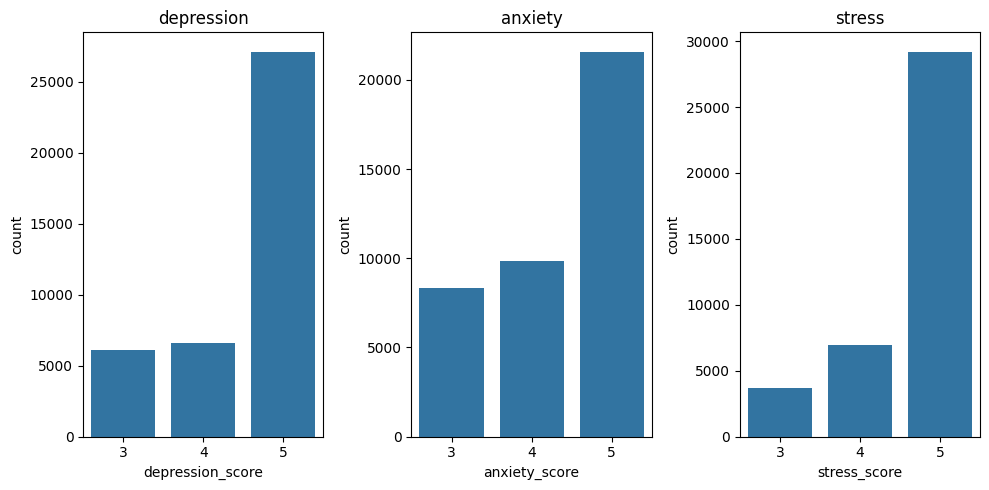

In [159]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 5))
axes = axes.ravel()
sns.countplot(x = data["depression_score"],ax = axes[0])
axes[0].set_title("depression")
sns.countplot(x = data["anxiety_score"],ax = axes[1])
axes[1].set_title("anxiety")
sns.countplot(x = data["stress_score"],ax = axes[2])
axes[2].set_title("stress")
plt.tight_layout()

([<matplotlib.axis.XTick at 0x131c9e810>,
 [Text(0, 0, 'LessthanHigh'),
  Text(1, 0, 'HighSchool'),
  Text(2, 0, 'University'),
  Text(3, 0, 'Graduate')])

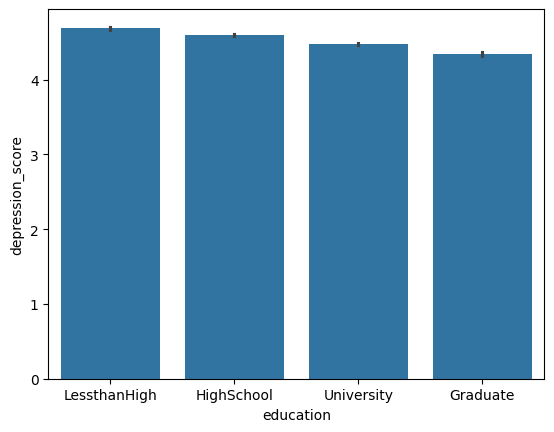

In [160]:
sns.barplot(x="education", y="depression_score", data=data[data["education"] != 0])
plt.xticks(ticks = range(len(data[data["education"] != 0]["education"].unique())), labels = ["LessthanHigh", "HighSchool", "University", "Graduate"])

([<matplotlib.axis.XTick at 0x131ebe480>,
 [Text(0, 0, 'Single'), Text(1, 0, 'Married'), Text(2, 0, 'Divorced')])

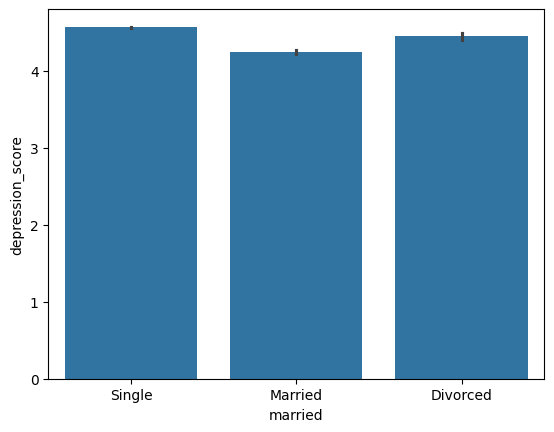

In [161]:
sns.barplot(x="married", y="depression_score", data=data[data["married"] != 0])
plt.xticks(ticks = range(len(data[data["married"] != 0]["married"].unique())), labels = ["Single", "Married", "Divorced"])

<Axes: xlabel='religion', ylabel='depression_score'>

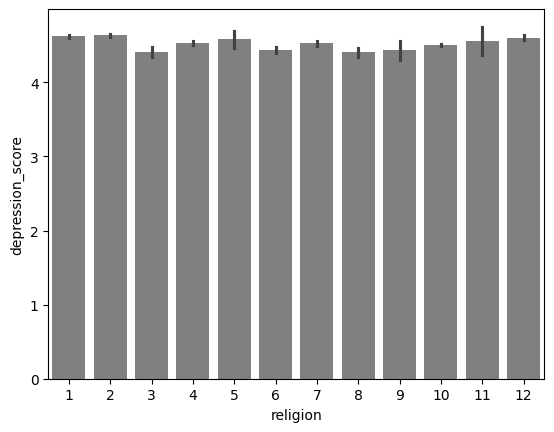

In [162]:
sns.barplot(data = data[data["religion"] != 0], x = "religion", y = "depression_score", color = "grey")

([<matplotlib.axis.XTick at 0x130ded3d0>,
 [Text(0, 0, 'Hetero'),
  Text(1, 0, 'Bi'),
  Text(2, 0, 'Homo'),
  Text(3, 0, 'A'),
  Text(4, 0, 'Other')])

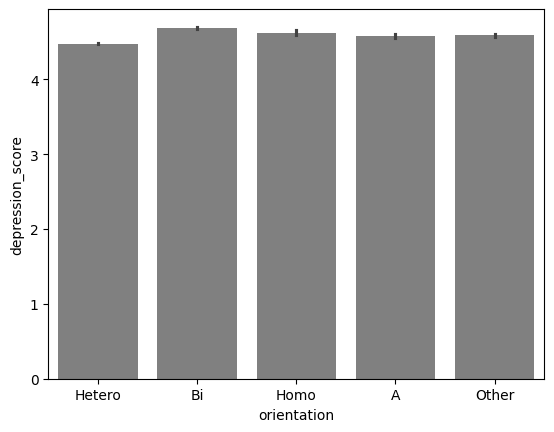

In [163]:
sns.barplot(data = data[data["orientation"] != 0], x = "orientation", y= "depression_score", color = "grey")
plt.xticks(ticks = range(len(data[data["orientation"] != 0]["orientation"].unique())), labels = ["Hetero", "Bi", "Homo", "A", "Other"])

In [164]:
dropped_questions = ["country", "source", "introelapse", "testelapse", "surveyelapse", "screensize", "uniquenetworklocation"]
for i in data.columns:
    if i.startswith("Q") and (i.endswith("I") or i.endswith("E")):
        dropped_questions.append(i)

data = data.drop(dropped_questions, axis=1)

In [165]:
categories = []
for label, item in data.items():
    if pd.api.types.is_object_dtype(item):
        categories.append(label)

In [166]:
numericals = []
for label, item in data.items():
    if pd.api.types.is_int64_dtype(item):
        numericals.append(label)

/var/folders/pd/hd4ggfd92s96hw2m79cprk4h0000gn/T/ipykernel_49297/3480842869.py:3: Pandas4Warning: is_int64_dtype is deprecated and will be removed in a future version. Use dtype == np.int64 instead.
  if pd.api.types.is_int64_dtype(item):


In [167]:
data_copy = data.copy()

In [168]:
data_copy.columns

Index(['Q1A', 'Q2A', 'Q3A', 'Q4A', 'Q5A', 'Q6A', 'Q7A', 'Q8A', 'Q9A', 'Q10A',
       'Q11A', 'Q12A', 'Q13A', 'Q14A', 'Q15A', 'Q16A', 'Q17A', 'Q18A', 'Q19A',
       'Q20A', 'Q21A', 'Q22A', 'Q23A', 'Q24A', 'Q25A', 'Q26A', 'Q27A', 'Q28A',
       'Q29A', 'Q30A', 'Q31A', 'Q32A', 'Q33A', 'Q34A', 'Q35A', 'Q36A', 'Q37A',
       'Q38A', 'Q39A', 'Q40A', 'Q41A', 'Q42A', 'TIPI1', 'TIPI2', 'TIPI3',
       'TIPI4', 'TIPI5', 'TIPI6', 'TIPI7', 'TIPI8', 'TIPI9', 'TIPI10', 'VCL1',
       'VCL2', 'VCL3', 'VCL4', 'VCL5', 'VCL6', 'VCL7', 'VCL8', 'VCL9', 'VCL10',
       'VCL11', 'VCL12', 'VCL13', 'VCL14', 'VCL15', 'VCL16', 'education',
       'urban', 'gender', 'engnat', 'age', 'hand', 'religion', 'orientation',
       'race', 'voted', 'married', 'familysize', 'major', 'depression_score',
       'anxiety_score', 'stress_score', 'extraversion', 'agreeableness',
       'conscientiousness', 'emotional_stability', 'openness'],
      dtype='str')

In [169]:
import pickle

data_copy = pd.get_dummies(data, columns=categories)
with open('onehot_columns.pkl', 'wb') as f:
    pickle.dump(data_copy.columns, f)

In [170]:
data_copy.columns

Index(['Q1A', 'Q2A', 'Q3A', 'Q4A', 'Q5A', 'Q6A', 'Q7A', 'Q8A', 'Q9A', 'Q10A',
       'Q11A', 'Q12A', 'Q13A', 'Q14A', 'Q15A', 'Q16A', 'Q17A', 'Q18A', 'Q19A',
       'Q20A', 'Q21A', 'Q22A', 'Q23A', 'Q24A', 'Q25A', 'Q26A', 'Q27A', 'Q28A',
       'Q29A', 'Q30A', 'Q31A', 'Q32A', 'Q33A', 'Q34A', 'Q35A', 'Q36A', 'Q37A',
       'Q38A', 'Q39A', 'Q40A', 'Q41A', 'Q42A', 'TIPI1', 'TIPI2', 'TIPI3',
       'TIPI4', 'TIPI5', 'TIPI6', 'TIPI7', 'TIPI8', 'TIPI9', 'TIPI10', 'VCL1',
       'VCL2', 'VCL3', 'VCL4', 'VCL5', 'VCL6', 'VCL7', 'VCL8', 'VCL9', 'VCL10',
       'VCL11', 'VCL12', 'VCL13', 'VCL14', 'VCL15', 'VCL16', 'education',
       'urban', 'gender', 'engnat', 'age', 'hand', 'religion', 'orientation',
       'race', 'voted', 'married', 'familysize', 'major', 'depression_score',
       'anxiety_score', 'stress_score', 'extraversion', 'agreeableness',
       'conscientiousness', 'emotional_stability', 'openness'],
      dtype='str')

In [171]:
data_copy

,Q1A,Q2A,Q3A,Q4A,Q5A,Q6A,Q7A,Q8A,Q9A,Q10A,...,familysize,major,depression_score,anxiety_score,stress_score,extraversion,agreeableness,conscientiousness,emotional_stability,openness
0,4,4,2,4,4,4,4,4,2,1,...,2,NaN,5,5,5,-6,2,2,-6,6
1,4,1,2,3,4,4,3,4,3,2,...,4,NaN,5,5,5,2,2,-3,-6,0
2,3,1,4,1,4,3,1,3,2,4,...,3,NaN,5,4,5,-4,0,-3,1,3
3,2,3,2,1,3,3,4,2,3,3,...,5,biology,5,5,5,-3,5,6,2,5
4,2,2,3,4,4,2,4,4,4,3,...,4,Psychology,5,5,5,-3,0,-3,-3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39770,2,1,3,2,3,2,1,3,1,4,...,2,NaN,5,4,5,-3,3,0,-2,0
39771,3,4,3,4,3,4,4,4,3,4,...,4,Mathematic,5,5,5,-2,-1,-2,-3,0
39772,2,1,2,1,1,1,1,1,2,1,...,3,Computer Science,3,3,3,3,0,6,0,2
39773,3,1,2,2,3,3,3,4,3,1,...,2,History,5,4,5,-4,-3,0,-4,-1


In [172]:
scores = ["depression_score", "anxiety_score", "stress_score"]

In [173]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(data_copy, test_size=0.2)

In [174]:
train_data_scores = train_data[scores]

In [175]:
train_data_scores

,depression_score,anxiety_score,stress_score
37009,4,5,5
12721,5,5,5
8545,4,5,5
30183,5,5,5
38185,5,5,5
...,...,...,...
27865,5,5,5
28752,5,5,5
21426,5,3,3
6744,5,5,5


In [176]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train_data_scores["depression_score"] = le.fit_transform(train_data_scores["depression_score"])
train_data_scores["anxiety_score"] = le.fit_transform(train_data_scores["anxiety_score"])
train_data_scores["stress_score"] = le.fit_transform(train_data_scores["stress_score"])

In [177]:
X = train_data.drop(scores, axis=1)

In [178]:
X.info()

<class 'pandas.DataFrame'>
Index: 31820 entries, 37009 to 37924
Data columns (total 86 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Q1A                  31820 non-null  int64
 1   Q2A                  31820 non-null  int64
 2   Q3A                  31820 non-null  int64
 3   Q4A                  31820 non-null  int64
 4   Q5A                  31820 non-null  int64
 5   Q6A                  31820 non-null  int64
 6   Q7A                  31820 non-null  int64
 7   Q8A                  31820 non-null  int64
 8   Q9A                  31820 non-null  int64
 9   Q10A                 31820 non-null  int64
 10  Q11A                 31820 non-null  int64
 11  Q12A                 31820 non-null  int64
 12  Q13A                 31820 non-null  int64
 13  Q14A                 31820 non-null  int64
 14  Q15A                 31820 non-null  int64
 15  Q16A                 31820 non-null  int64
 16  Q17A                 31820 non-nul

In [179]:
X = pd.get_dummies(X, drop_first=True)

In [180]:
depression_y = train_data_scores["depression_score"]
anxiety_y = train_data_scores["anxiety_score"]
stress_y = train_data_scores["stress_score"]

## For Predicting Depression

In [181]:
X
depression_y

37009    1
12721    2
8545     1
30183    2
38185    2
        ..
27865    2
28752    2
21426    2
6744     2
37924    2
Name: depression_score, Length: 31820, dtype: int64

In [182]:
from sklearn.model_selection import train_test_split

X_train, X_test, depression_y_train, depression_y_test = train_test_split(X, depression_y, test_size=0.2, random_state=42)

In [183]:
from sklearn.svm import LinearSVC

clf = LinearSVC()

clf.fit(X_train, depression_y_train)
clf.score(X_test, depression_y_test)

0.9795725958516657

In [184]:
depression_preds = clf.predict(X_test)
depression_preds[:10]

array([2, 2, 2, 0, 1, 2, 0, 2, 0, 1])

In [185]:
from sklearn.metrics import confusion_matrix, classification_report

conf = confusion_matrix(depression_preds, depression_y_test)

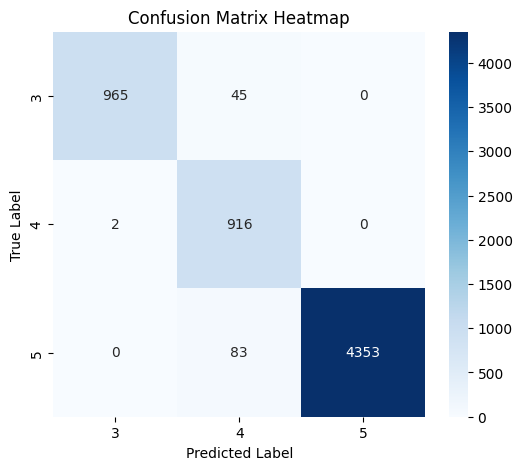

In [186]:
plt.figure(figsize=(6, 5))
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues', xticklabels=[3,4,5], yticklabels=[3,4,5])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [187]:
print(classification_report(depression_preds, depression_y_test))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1010
           1       0.88      1.00      0.93       918
           2       1.00      0.98      0.99      4436

    accuracy                           0.98      6364
   macro avg       0.96      0.98      0.97      6364
weighted avg       0.98      0.98      0.98      6364



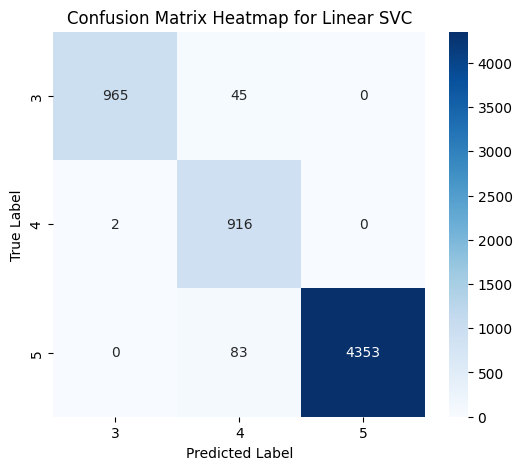

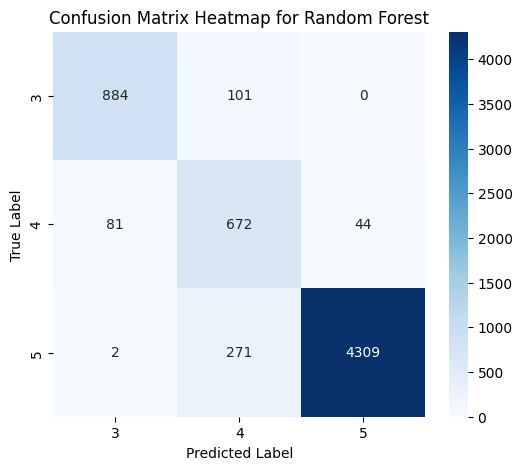

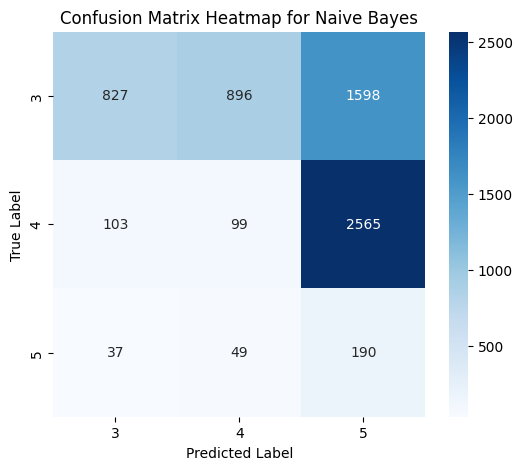

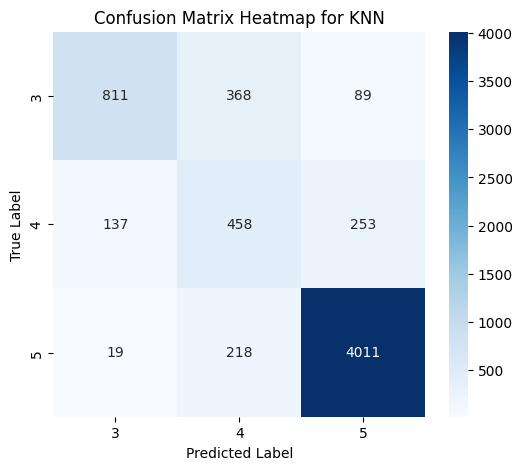

/Users/aryanmanchanda/Projects/Aura_Check/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


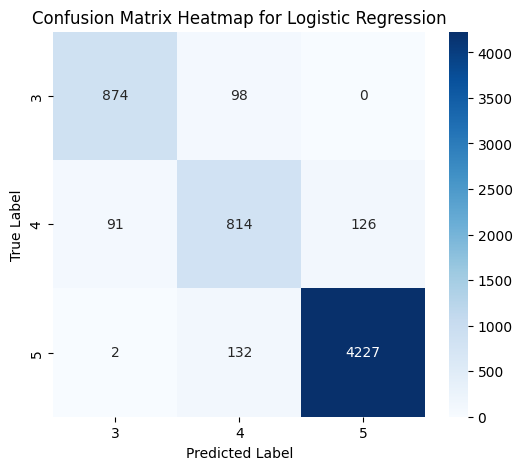

In [188]:
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

models = {"Linear SVC": LinearSVC(), "Random Forest": RandomForestClassifier(), "Naive Bayes": GaussianNB(), "KNN": KNeighborsClassifier(), "Logistic Regression": LogisticRegression()}
model_scores = {}

for name, model in  models.items():
    model.fit(X_train, depression_y_train)
    b = model.score(X_test, depression_y_test)
    model_scores[name] = b
    a = model.predict(X_test)
    conf = confusion_matrix(a, depression_y_test)
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf, annot=True, fmt='d', cmap='Blues', xticklabels=[3,4,5], yticklabels=[3,4,5])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix Heatmap for {name}")
    plt.show()

In [189]:
model_scores

{'Linear SVC': 0.9795725958516657,
 'Random Forest': 0.9215901948460088,
 'Naive Bayes': 0.17536140791954746,
 'KNN': 0.8296668761785041,
 'Logistic Regression': 0.9294468887492143}

In [190]:
from xgboost import XGBClassifier

xgc = XGBClassifier()
xgc.fit(X_train, depression_y_train)
xgc.score(X_test, depression_y_test)

0.9797297297297297

In [191]:
depression_preds_xgc = xgc.predict(X_test)

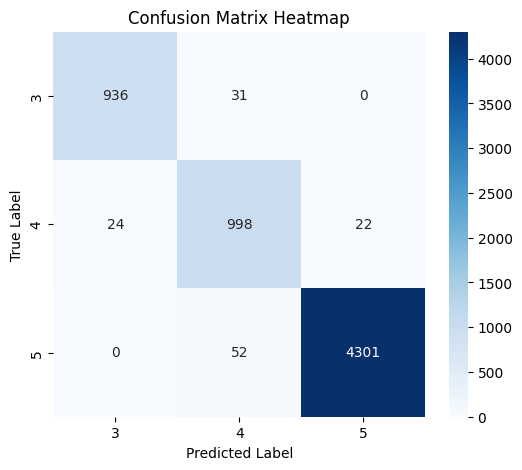

In [192]:
from sklearn.metrics import confusion_matrix, classification_report

conf = confusion_matrix(y_pred=depression_preds_xgc, y_true=depression_y_test)
plt.figure(figsize=(6, 5))
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues', xticklabels=[3,4,5], yticklabels=[3,4,5])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [193]:
print(classification_report(depression_y_test, depression_preds_xgc))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       967
           1       0.92      0.96      0.94      1044
           2       0.99      0.99      0.99      4353

    accuracy                           0.98      6364
   macro avg       0.96      0.97      0.97      6364
weighted avg       0.98      0.98      0.98      6364



In [194]:
import pickle

pickle.dump(xgc, open("../models/xgc_model1_depression.pkl", "wb"))

## Anxiety Prediction

In [195]:
X
# anxiety_y

,Q1A,Q2A,Q3A,Q4A,Q5A,Q6A,Q7A,Q8A,Q9A,Q10A,...,major_veterinarian,major_veterinary,major_veterinary,major_veterinary medicine,major_veterinary medicine,major_visual arts and culture,major_water engineering,major_writing,major_writing,major_zoology
37009,2,4,1,3,2,2,3,2,4,1,...,False,False,False,False,False,False,False,False,False,False
12721,4,2,4,4,4,4,4,4,4,4,...,False,False,False,False,False,False,False,False,False,False
8545,2,1,1,1,1,3,2,3,3,2,...,False,False,False,False,False,False,False,False,False,False
30183,4,4,2,2,4,4,3,4,4,4,...,False,False,False,False,False,False,False,False,False,False
38185,3,3,3,3,4,3,1,4,4,2,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27865,3,1,2,4,4,1,4,3,2,1,...,False,False,False,False,False,False,False,False,False,False
28752,3,2,2,3,1,3,3,2,4,2,...,False,False,False,False,False,False,False,False,False,False
21426,1,1,1,1,1,1,1,1,1,4,...,False,False,False,False,False,False,False,False,False,False
6744,3,1,3,3,4,2,2,2,3,4,...,False,False,False,False,False,False,False,False,False,False


In [196]:
from sklearn.model_selection import train_test_split

X_train, X_test, anxiety_y_train, anxiety_y_test = train_test_split(X, anxiety_y, test_size=0.2)

In [197]:
from xgboost import XGBClassifier

xgc = XGBClassifier()
xgc.fit(X_train, anxiety_y_train)
xgc.score(X_test, anxiety_y_test)

0.9718730358265242

In [198]:
anxiety_preds = xgc.predict(X_test)

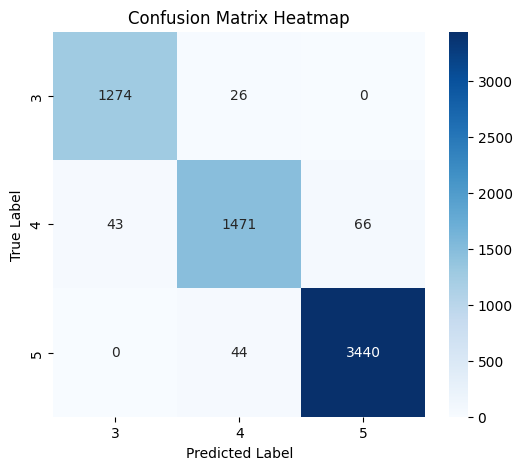

In [199]:
from sklearn.metrics import confusion_matrix, classification_report

conf = confusion_matrix(anxiety_preds, anxiety_y_test)
plt.figure(figsize=(6, 5))
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues', xticklabels=[3,4,5], yticklabels=[3,4,5])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [200]:
print(classification_report(anxiety_y_test, anxiety_preds))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97      1317
           1       0.93      0.95      0.94      1541
           2       0.99      0.98      0.98      3506

    accuracy                           0.97      6364
   macro avg       0.97      0.97      0.97      6364
weighted avg       0.97      0.97      0.97      6364



In [201]:
import pickle

pickle.dump(xgc, open("../models/xgc_model1_anxiety.pkl", "wb"))

## Stress Prediction

In [202]:
X
stress_y

37009    2
12721    2
8545     2
30183    2
38185    2
        ..
27865    2
28752    2
21426    0
6744     2
37924    1
Name: stress_score, Length: 31820, dtype: int64

In [203]:
from sklearn.model_selection import train_test_split

X_train, X_test, stress_y_train, stress_y_test = train_test_split(X, stress_y, test_size=0.2)

In [204]:
from xgboost import XGBClassifier

xgc = XGBClassifier()
xgc.fit(X_train, stress_y_train)
xgc.score(X_test, stress_y_test)

0.9784726587052168

In [205]:
stress_preds = xgc.predict(X_test)

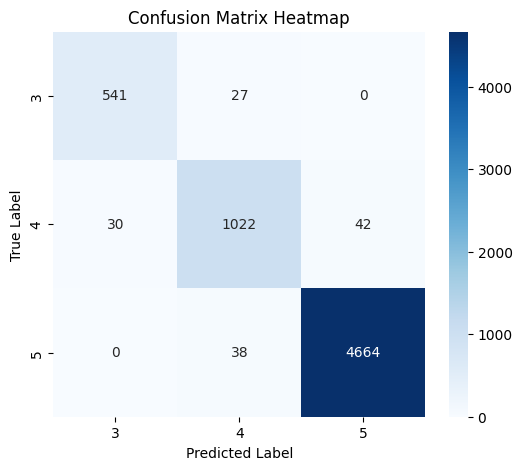

In [206]:
from sklearn.metrics import confusion_matrix, classification_report

conf = confusion_matrix(stress_preds, stress_y_test)
plt.figure(figsize=(6, 5))
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues', xticklabels=[3,4,5], yticklabels=[3,4,5])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [207]:
print(classification_report(stress_y_test, stress_preds))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       571
           1       0.93      0.94      0.94      1087
           2       0.99      0.99      0.99      4706

    accuracy                           0.98      6364
   macro avg       0.96      0.96      0.96      6364
weighted avg       0.98      0.98      0.98      6364



In [208]:
import pickle

pickle.dump(xgc, open("../models/xgc_model1_stress.pkl", "wb"))

## Testing

In [217]:
import pickle

model = pickle.load(open("../models/xgc_model1_anxiety.pkl", 'rb'))

In [218]:
test_preds_anxiety = model.predict(X)

In [220]:
from sklearn.metrics import confusion_matrix, classification_report, matthews_corrcoef

print(classification_report(anxiety_y, test_preds_anxiety))
print(matthews_corrcoef(y_true=anxiety_y, y_pred=test_preds_anxiety))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      6656
           1       0.99      0.99      0.99      7906
           2       1.00      1.00      1.00     17258

    accuracy                           0.99     31820
   macro avg       0.99      0.99      0.99     31820
weighted avg       0.99      0.99      0.99     31820

0.9906346426884316


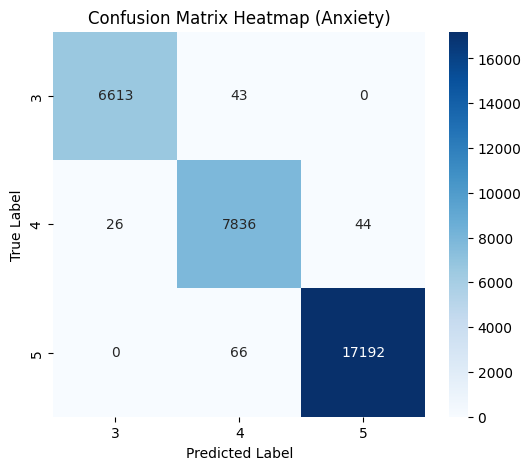

In [221]:
conf = confusion_matrix(y_true=anxiety_y, y_pred=test_preds_anxiety)
plt.figure(figsize=(6, 5))
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues', xticklabels=[3,4,5], yticklabels=[3,4,5])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap (Anxiety)")
plt.show()

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      4877
           1       0.98      0.99      0.99      5259
           2       1.00      1.00      1.00     21684

    accuracy                           1.00     31820
   macro avg       0.99      0.99      0.99     31820
weighted avg       1.00      1.00      1.00     31820


0.9916489892529864



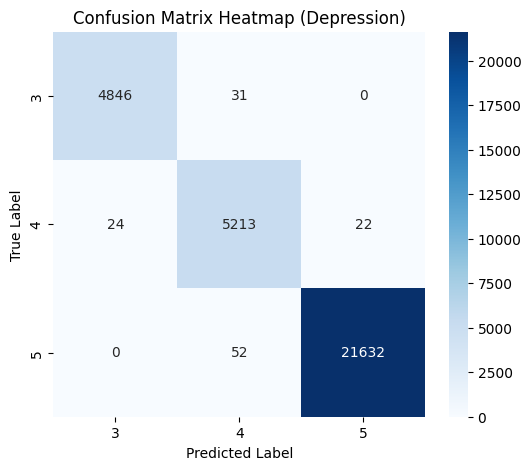

In [222]:
import pickle

model = pickle.load(open("../models/xgc_model1_depression.pkl", 'rb'))

test_preds_depression = model.predict(X)

from sklearn.metrics import confusion_matrix, classification_report, matthews_corrcoef

print(classification_report(depression_y, test_preds_depression))
print()
print(matthews_corrcoef(y_true=depression_y, y_pred=test_preds_depression))
print()
conf = confusion_matrix(y_true=depression_y, y_pred=test_preds_depression)
plt.figure(figsize=(6, 5))
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues', xticklabels=[3,4,5], yticklabels=[3,4,5])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap (Depression)")
plt.show()

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2943
           1       0.99      0.99      0.99      5467
           2       1.00      1.00      1.00     23410

    accuracy                           1.00     31820
   macro avg       0.99      0.99      0.99     31820
weighted avg       1.00      1.00      1.00     31820


0.9897668845742214



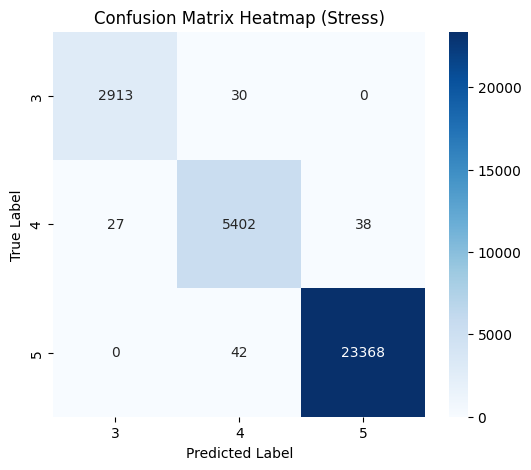

In [223]:
import pickle

model = pickle.load(open("../models/xgc_model1_stress.pkl", 'rb'))

test_preds_stress = model.predict(X)

from sklearn.metrics import confusion_matrix, classification_report, matthews_corrcoef

print(classification_report(stress_y, test_preds_stress))
print()
print(matthews_corrcoef(y_true=stress_y, y_pred=test_preds_stress))
print()
conf = confusion_matrix(y_true=stress_y, y_pred=test_preds_stress)
plt.figure(figsize=(6, 5))
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues', xticklabels=[3,4,5], yticklabels=[3,4,5])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap (Stress)")
plt.show()

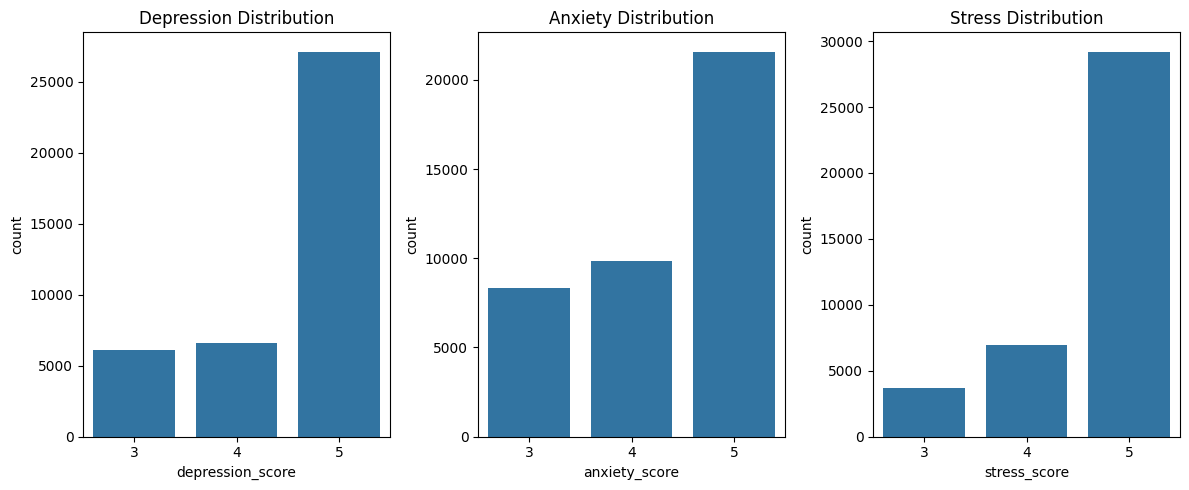

In [224]:
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
sns.countplot(x=data["depression_score"])
plt.title("Depression Distribution")

plt.subplot(1,3,2)
sns.countplot(x=data["anxiety_score"])
plt.title("Anxiety Distribution")

plt.subplot(1,3,3)
sns.countplot(x=data["stress_score"])
plt.title("Stress Distribution")

plt.tight_layout()
plt.show()

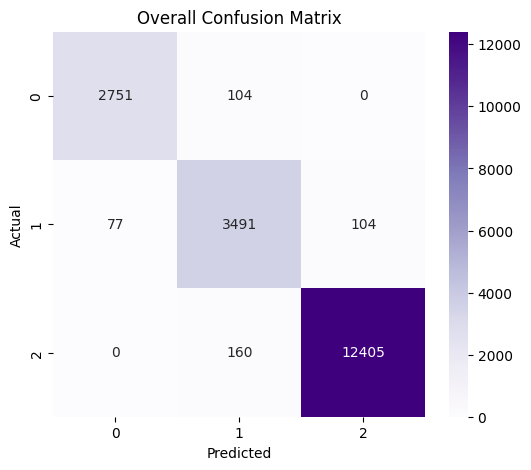

In [225]:
y_true = pd.concat([depression_y_test, anxiety_y_test, stress_y_test])
y_pred = np.concatenate([depression_preds_xgc, anxiety_preds, stress_preds])

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("Overall Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

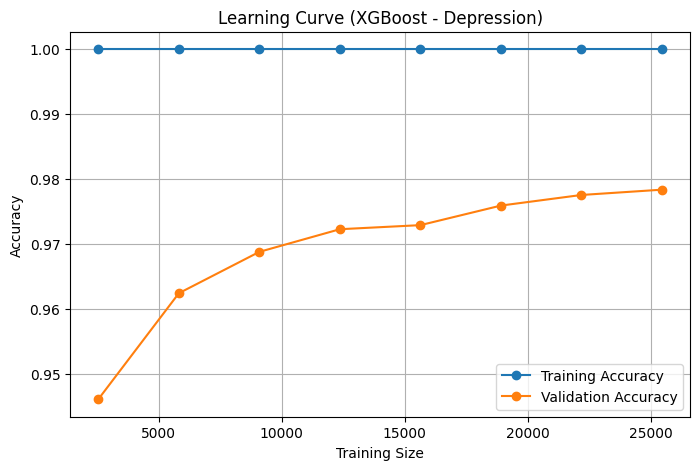

In [226]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    xgc, X, depression_y,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 8)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, marker='o', label="Training Accuracy")
plt.plot(train_sizes, test_mean, marker='o', label="Validation Accuracy")

plt.title("Learning Curve (XGBoost - Depression)")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()